# Defining product categories

For this code along we are only going to use the `products` DataFrame. However, if you believe there is information in other tables that can help to create categories, please feel free to explore.

In [ ]:
import pandas as pd

In [ ]:
# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [ ]:
product_category_df = products_cl.copy()

In [ ]:
product_category_df.head(20)

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364
5,APP0073,Apple Composite AV Cable iPhone and iPod white,IPhone and iPod AV Cable Dock to Composite Video.,45.00,0,1230
6,KIN0008,Mac Memory Kingston 1GB 667MHz DDR2 SO-DIMM,1GB RAM Mac mini and iMac (2006/07) MacBook Pr...,18.99,0,1364
7,KIN0009,Mac Memory Kingston 2GB 800MHz DDR2 SO-DIMM,2GB RAM iMac with Intel Core 2 Duo (Penryn).,36.99,0,1364
8,KIN0001-2,Mac memory Kingston 4GB (2x2GB) 667MHz DDR2 SO...,RAM 4GB (2x2GB) Mac mini and iMac (2006/07) Ma...,74.00,0,1364
9,APP0100,Apple Adapter Mini Display Port to VGA,Adapter Mini Display Port to VGA MacBook and M...,35.00,0,1325


We can see a lot of possible hints how to find a product's category:

- the `name` might be already enough to identify a product and its category
- we are not all tech experts, maybe the `desc` is needed in addition to the `name` to define a category
- what is actually the `type` column telling us? Isn't a product type the same as a product category?

Before we try out each approach, let's set up a designated `category` column in our dataframe. For now, let's just fill it with a placeholder indicating that no category was attributed yet:

In [ ]:
product_category_df["category"] = ""
product_category_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,


# 1. The `type` column

We have the mysterious column `type` in the products table. This could potentially be ready-made categories labelled with numbers instead of words. Let's investigate.

## 1.1 The largest types

Let's find the types that contain the most products:

In [ ]:
product_category_df["type"].value_counts().iloc[:10]

,count
type,
11865403,1057
12175397,939
1298,783
11935397,562
11905404,454
1282,373
12635403,362
13835403,269
"5,74E+15",247


This looks promising. Some types contain already a large portion of our overall products.

But let's also check how many different types there are in total:

In [ ]:
product_category_df["type"].nunique()

125

Oh, that's a lot. But do we really need all? Before we answer that, let's take a look at the largest types and see whether it even makes sense to follow this path any further.

Let's have a look at the first `type` to see if we can make categories from this column.

In [ ]:
product_category_df.loc[product_category_df["type"] == "11865403"].sample(10)

,sku,name,desc,price,in_stock,type,category
5080,PUR0148,"Pure Nude Ultraslim 03 ""iPhone Case 8 Plus / 7...",transparent and flexible cover with 03mm thick...,13.99,1,11865403,
1754,NTE0092,NewerTech NuGuard KX iPhone 6 Plus Case Red,Ultra Rugged Case for iPhone 6 Plus.,72.99,0,11865403,
6895,GRT0466,Griffin Survivor Case Tough Journey iPhone 7 /...,Cast and impact resistant padded case for iPho...,29.99,0,11865403,
4253,APP1552,Leather Case Apple iPhone 6 / 6S Navy,ultrathin leather case and microfiber premium ...,55.00,0,11865403,
2409,KUA0027,Support Kukaclip car + iPhone Case 6 / Transpa...,Magnetic car holder with 360 degrees rotating ...,24.99,0,11865403,
197,MUV0042,Clear Back Case Muvit iPhone / 5s / 5 transparent,iPhone back cover tranparente SE / 5s / 5.,9.99,0,11865403,
7799,AP20208,Second hand - Apple Leather Case Cover iPhone ...,Reconditioned ultrathin leather case and micro...,59.00,0,11865403,
3319,SNA0062,Sena UltraSlim Case Heritage iPhone 6 / 6S bro...,Ultra Thin Skin Case for iPhone 6 / 6S Plus.,39.95,0,11865403,
8179,MUJ0035,Mujjo Full Leather Skin Case iPhone X Tan,Case ultrafine material vegetable tanned leath...,49.90,1,11865403,
1747,NTE0085,NewerTech NuGuard KX iPhone Case 6 / 6s Black,iPhone ultra resistant casing 6 and 6s,60.99,0,11865403,


Looks like this is a category of phone cases.
If you are not confident yet, run the cell above several times to take a look at different samples.

Let's have a look at the 2nd largest type to see if that's also a clear category.

In [ ]:
product_category_df.loc[product_category_df["type"] == "12175397"].sample(10)

,sku,name,desc,price,in_stock,type,category
5035,PAC1682,Pack QNAP TS-251A NAS Server | 2GB RAM | Seaga...,NAS with 2GB of RAM and 6TB (2x3TB) Seagate Ir...,629.67,0,12175397,
1082,PAC0520,Synology DS115j Pack | WD 4TB Network,Synology DS115j NAS Server Pack + 4TB WD Netwo...,260.99,0,12175397,
7068,PAC1960,Synology DS1817 + | 2GB RAM | 80TB (8x10TB) Se...,NAS server with 2GB of RAM and 80TB for Mac an...,4178.81,0,12175397,
8813,PAC2455,DS218J Synology NAS Server | 4TB (2x2TB) Seaga...,2-bay NAS server entry-level to back domestic ...,405.97,0,12175397,
1247,PAC1826,Synology DS1515 + l l 8GB RAM 20TB (5x4TB) WD Red,Synology DS1815 + NAS memory 8GB hard drive WD...,1880.97,0,12175397,
5949,PAC1771,QNAP TS-431P NAS,NAS with 24TB capacity WD Red hard drives for ...,1321.99,0,12175397,
3859,PAC1736,QNAP TS-128 Server l Nas 3TB (1x3TB) WD Red,NAS TS-128 1 3TB hard drive for Mac and PC,247.99,0,12175397,
4375,PAC1435,Synology DS916 + Pack | 8GB RAM | WD 32TB Network,Synology DS916 + with 8GB of RAM memory + 32TB...,2065.20,0,12175397,
4388,PAC1852,Synology DS916 + | 8GB RAM | 24TB (4x6TB) Seag...,DS916 + NAS with 24TB + 8GB RAM memory (4x6TB)...,1749.16,0,12175397,
8491,PAC2394,DS418play Synology NAS Server | 6GB RAM | 8TB ...,4-bay NAS server to accommodate 4K Ultra HD files,996.94,0,12175397,


Looks like this category is full of servers.

Let's set the categories accordingly:

In [ ]:
product_category_df.loc[product_category_df["type"] == "11865403", "category"] = "Cases"
product_category_df.loc[product_category_df["type"] == "12175397", "category"] = "Servers"
product_category_df.sample(10)

,sku,name,desc,price,in_stock,type,category
8281,XDO0048,X-Doria Defense Clear iPhone Case 8 Plus / 7 Plus,protection and shock absorption in triplicate ...,24.99,0,11865403,Cases
8191,ELA0046,Elago S8 Slim Fit 2 X Polycarbonate Case Silve...,minimalist and elegant but full protection det...,24.99,1,11865403,Cases
9541,SPE0178-A,Open - Speck iPhone Case 7 Clear Presidio,Reconditioned slip cover with slim design and ...,24.95,0,11865403,Cases
2700,PAC1624,"Apple iMac 27 ""Core i5 3.3GHz Retina 5K | 32GB...",Desktop computer iMac 27-inch 3.3GHz Core i5 5...,5089.00,0,"5,74E+15",
7559,APP2208,"Apple iMac 21.5 ""Core i5 3.4GHz 4K Retina | 8G...",PC 215 inch iMac with 8GB RAM 512GB SSD PCle,2059.00,0,"2,16E+11",
7924,AP20258,Like new - Apple iPhone 16GB Silver,Apple iPhone SE Free Refurbished 16GB Color Si...,489.00,0,51601716,
7193,AKI0019,Akitio Thunder2 QUAD Case External Thunderbolt 2,Disk outer box 25 inch and 35 inch Thunderbolt...,468.00,0,12995397,
2256,TRI0028,Tribe External Battery Power Bank 2600 mAh Min...,2600mAh external battery for iPhone small and ...,19.99,0,1515,
5047,LIF0089-A,(Open) Lifeproof Fre Power 2600mAh Battery Cas...,Submersible battery cover with water up to 2 m...,129.99,0,1298,
6478,GRT0453,Griffin Survivor iPhone Case 7 Summit Plus Bla...,hard case with screen protector and clip suppo...,49.99,0,11865403,Cases


Let's continue with the third largest `type`:

In [ ]:
product_category_df.loc[product_category_df["type"] == "1298"]

,sku,name,desc,price,in_stock,type,category
453,BEL0127-A,Open - Belkin MIXIT Lightning iPhone Support,Loading dock + support synchronization with Li...,34.99,0,1298,
1071,SEA0043-A,"Open - Seagate Barracuda 1TB 35 ""SATA 7200rpm ...",internal hard drive for Mac and PC Refurbished...,59.00,0,1298,
1445,WDT0175-A,"Open - Western Digital 2TB Green 35 ""5400rpm h...",WD Internal Hard Drive 2TB Mac and PC.,90.00,0,1298,
1499,NTE0056-A,Open - NewerTech NuPower Battery 65W MacBook P...,MacBook Pro 13 inch Battery 2009/14,131.99,0,1298,
1511,BNQ0018-A,"(Open) LED Monitor BenQ VW2235H 215 """,Monitor 215 inch high range.,163.00,0,1298,
...,...,...,...,...,...,...,...
8670,LGE0061-A,"Open - LG 43UD79-B Monitor 425 ""4K 72% NTSC US...",425 inch monitor 5ms response DisplayPort and ...,845.99,0,1298,
8671,QNA0190-A,Open - QNAP TS-853U NAS Server | 4GB RAM,8-bay NAS server for small businesses with 4 E...,1511.29,0,1298,
8879,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,29.99,0,1298,
9469,ZAG0024-A,Open - Zagg Folio Case with Keyboard Cover iPa...,Reconditioned Case with Bluetooth Keyboard for...,79.99,0,1298,


Oh no, this seems to be a mix of completely different products. We can see some hard drives, some monitors, and other accessories.

Not all types will work as nicely as the first two, but it will definitely be worth investigating some more. We leave this up to you though and will not continue here.

## 1.2 How many types need to be analyzed?

We have seen that the `type` column can do pretty good work in finding categories, but it won't do it alone.

Before continuing with alternative approaches, let's answer our previous question:

How many types need to be analyzed?

Maybe it is enough to just analyze the largest `n` types. The remaining ones could then be labeled as `others` or similar.

But which `n` would be sufficient?

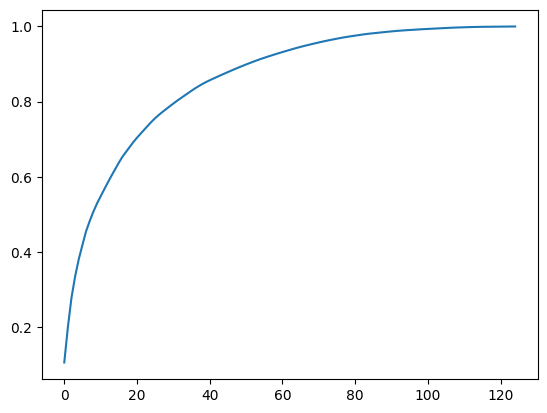

In [ ]:
(
    product_category_df["type"]
    .value_counts(normalize=True)
    .reset_index(drop=True)
    .cumsum()
    .plot()
);

Okay, that's promising. We could already achieve a decent coverage by focusing mainly on the top 20-30 types.

# 2. Category creation using regex

While we saw that a lot of products will already be labeled purely based on their `type`, others will need a more sophisticated approach.

This will be true for many datasets you encounter throughout your career. You won't always be lucky enough to have a column like `type` that does most of the work for you.

Let's see how string methods, in particular `.str.contains`, and `regex` could help us.

## 2.1 The `desc` column

We can find all the products with certain words in their description (`desc`) using `.loc[]` and `.str.contains()`.

We saw that our mixed type contained some monitors. Let's look at all the items that have the word `monitor` in their description.

In [ ]:
product_category_df.loc[product_category_df["desc"].str.contains("monitor", case=False)].head(10)

,sku,name,desc,price,in_stock,type,category
50,APP0344,"Apple Thunderbolt Display 27 ""Monitor Mac",Monitor Display 27-inch Apple Thunderbolt (MC9...,1149.00,0,1296,
268,FIT0013,Fitbit ZIP monitor green activity,Activity Monitor compact and lightweight.,59.99,0,11905404,
298,WAH0008,Wahoo Fitness Blue HR heart rate monitor iPhon...,Wireless heart rate monitor iPhone iPad and iP...,79.99,0,11905404,
415,RUN0007,Runware RunAlyzer Blue Ribbon cardio bluetooth,Band wireless heart rate monitor iPhone iPad a...,69.99,0,11905404,
581,BNQ0024,"BenQ LED Monitor VW2235H 215 """,Monitor 215 inch high range.,129.00,0,1296,
608,DLK0057,D-Link DCS-825L camera EyeOn Wi-Fi baby monitor,baby monitor camera with night vision SD card ...,227.00,0,9094,
610,BNQ0023,"Benq GL2460HM Monitor Full HD 24 ""Black",LCD Monitor 24-inch high-definition HDMI conne...,158.00,0,1296,
653,PAR0014,Parrot Flower Power Plants Wireless Sensor Blue,Plants Wireless Sensor Monitor for iPhone.,59.95,0,11905404,
655,SYN0088,Synology Surveillance Station VS240HD,monitoring station to monitor up to 24 IP came...,453.99,0,12175397,Servers
659,BNQ0027,"BL2710PT BenQ Monitor 27 ""WQHD resolution for CAD",27-inch WQHD Professional monitor for CAD CAM ...,499.00,0,1296,


This seems like a good approach. Almost all matches are indeed monitors. But we can also see a `Server` showing up as it is a **monitor**ing station. To not override its `category`, let's only filter for products which have no `category` yet and set for these the `category` to `Monitors`.

In [ ]:
product_category_df.loc[(product_category_df["desc"].str.contains("monitor", case=False))
                        & (product_category_df["category"] == ""), "category"] = "Monitors"

Let's take a look at the effect that had on the `category` column.

In [ ]:
product_category_df["category"].value_counts()

,count
category,
,7689
Cases,1057
Servers,939
Monitors,307


## 2.2 The product `name`
We can also use a product's `name` to select products for our categories.

In [ ]:
product_category_df.loc[product_category_df["name"].str.contains("apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category
35,APP0308,AV Cable Adapter Apple iPhone iPad and iPod white,IPhone iPad iPod adapter and AV cable.,45.00,0,1230,
214,REP0100,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
215,REP0052,Color change to White Apple iPhone 4,It is including parts and labor..,94.21,0,"1,44E+11",
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN,
...,...,...,...,...,...,...,...
9790,AP20455,Like new - Apple iPhone 8 256GB Gold,Apple iPhone 8 reconditioned 256GB in Gold rea...,979.00,0,113291716,
9794,APP2482-A,Open - Apple iPhone 8 Plus 256GB Gold,Refurbished Apple iPhone 8 Plus 256GB Free Gold,1089.00,0,113281716,
9929,APP2477-A,Open - Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray,919.00,0,113281716,
9958,AP20467,Like new - Apple iPhone Silicone Case Cover 7 ...,Reconditioned silicone sleeve microfiber Apple...,45.00,0,11865403,Cases


Looks like we get a lot of accessories included in this search.

However, there seem to be some underlying patterns which could tell us whether or not a product is an iPhone.

We can refine our search using a little regex. Here, we will add `.{0,7}` at the beginning of the search: this means we will find all `apple iphone`s that have 7 or less characters preceding the term "apple iphone" - if there's 8 characters preceding the search term, it won't be found. This should help refine our search by using the nomenclature of the DataFrame to our advantage.

If you feel unsure about regex, please use [regex101](https://regex101.com/). It's really useful for checking your code, and parts of other people's code that you're unsure about.

In [ ]:
product_category_df.loc[product_category_df["name"].str.contains("^.{0,7}apple iphone", case=False)]

,sku,name,desc,price,in_stock,type,category
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.0,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.0,0,NaN,
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.0,0,NaN,
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.0,0,NaN,
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.0,0,NaN,
...,...,...,...,...,...,...,...
9585,APP1634-A,Open - Apple iPhone 7 Plus 32GB Black,New 32GB Apple iPhone 7 Plus Free Black,779.0,0,85651716,
9587,APP2540-A,Open - Apple iPhone Leather Folio X Baya,Leather case with box and official cover Apple,109.0,0,11865403,Cases
9714,APP2562-A,Open - Apple iPhone Leather Case Cover Red,Reconditioned skin sheath official Apple desig...,45.0,0,11865403,Cases
9794,APP2482-A,Open - Apple iPhone 8 Plus 256GB Gold,Refurbished Apple iPhone 8 Plus 256GB Free Gold,1089.0,0,113281716,


Now we can use the same trick as before to set the category - selecting the `category` column and setting it to the string of our choice.

In [ ]:
product_category_df.loc[(product_category_df["name"]
                        .str.contains("^.{0,7}apple iphone", case=False))
                        & (product_category_df["category"] == ""),
                        "category"] = "Smartphones"

With `regex`, we are additionally also able to search for multiple possible matches at the same time using the or operator `|`:


In [ ]:
product_category_df.loc[(product_category_df["name"]
                        .str.contains("imac|mac mini|mac pro", case=False))
                        & (product_category_df["category"] == ""),
                        "category"] = "Desktops"

Let's take another look at our `category` counts:

In [ ]:
product_category_df["category"].value_counts()

,count
category,
,6614
Cases,1057
Servers,939
Desktops,921
Monitors,307
Smartphones,154


# Challenge: Your categories
Now it's your turn. We'll reset the Dataframe so that no categories exist, and it's up to you to create the categories based on either the type, keywords in the name and description, or a combination of both.

Feel free to go wild and make as many categories as you like.

In [ ]:
# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

product_category_df = products_cl.copy()

product_category_df["category"] = ""

In [ ]:
# your code here

-----

# [Bonus] Grouping products by other characteristics

Beyond the normal product type categories, it might be beneficial to perform your analysis also on other kinds of products groupings.

Those could for example be:
- The product's price
- The product's manufacturer (Have you realized yet how to connect the `products` and the `brands` table? If not, take a look at the `sku`.)

# [Bonus] Creating sub-categories
While we searched for desktop computers, we saw that we found iMacs, Mac Minis, and Mac Pros. Sometimes it might be insightful to investigate each independently. However, placing them in separate categories could be an overkill as it would affect all analyses.

In such cases, adding another tag, a `sub_category`, could be helpful:

In [ ]:
product_category_df["sub_category"] = ""

product_category_df.loc[product_category_df["name"]
                        .str.contains("imac|mac mini|mac pro", case=False),
                        "category"] = "desktop"

product_category_df.loc[product_category_df["name"]
                        .str.contains("imac", case=False),
                        "sub_category"] = "iMac"
product_category_df.loc[product_category_df["name"]
                        .str.contains("mac mini", case=False),
                        "sub_category"] = "Mac Mini"
product_category_df.loc[product_category_df["name"]
                        .str.contains("mac pro", case=False),
                        "sub_category"] = "Mac Pro"

product_category_df.loc[product_category_df['category'] == "desktop"]

,sku,name,desc,price,in_stock,type,category,sub_category
64,HGD0012,Henge Docks Click keyboard support iMac,Base to hold the Apple Magic TrackPad and Wire...,29.00,0,8696,desktop,iMac
92,OWC0008,OWC Data Doubler Optical Bay Adapter Mac Mini ...,Tray substitution of superdrive by hard drive ...,72.99,1,12755395,desktop,Mac Mini
121,SNN0016,Sonnet XMAC mini Server,Turn your Mac mini Server Rack format,1208.79,0,12175397,desktop,Mac Mini
147,NTE0044,"NewerTech windy 225 ""for iMac",Suction cup 225 inches for aluminum iMac.,11.99,1,14305406,desktop,iMac
153,OWC0024,OWC Mount Adapter 25-35 Pro Mac Pro (2009-2012),SSD hard drive adapter or 2.5 for Mac Pro.,35.99,1,12755395,desktop,Mac Pro
...,...,...,...,...,...,...,...,...
9693,PAC2507,Keyboard Replacement numerical Wireless iMac,Keyboard replacement service at the time of pu...,149.00,1,13855401,desktop,iMac
9748,APP2211-A,"Open - Apple iMac 27 ""Core i5 Retina 5K 34GHz ...",IMac desktop computer 27 inch 5K Retina 8GB RA...,2459.00,0,"5,74E+15",desktop,iMac
9749,APP2229-A,"Open - Apple iMac 27 ""Core i7 Retina 5K 42GHz ...",IMac desktop computer 27 inch 5K Retina 8GB RA...,4519.00,0,"5,74E+15",desktop,iMac
9830,TWS0035-A,Open - Twelve South HiRise for iMac & Cinema D...,Reconditioned adjustable and adjustable drawer...,89.99,0,8696,desktop,iMac


There is no right or wrong. Be creative and find the approach that works best for you and your group.

# [Bonus] Create functions

If you want to do a particular task repeatedly, wrapping it into a function can make your life much easier. Let's take another look at the regex approach. Which information were needed to perform the categorization:

- the dataframe we work with
- the column name (`name` or `desc`)
- the regex pattern
- the designated category label

Perfect, we know which input parameters our function will need!

In [ ]:
def set_category_from_regex(df_name, column_name, regex_pattern, category_name):
    df_name.loc[(df_name[column_name]
            .str.contains(regex_pattern, case=False))
            & (df_name["category"] == ""),
            "category"] = category_name

Wasn't that easy?

Let's try it out with our previous patterns:

In [ ]:
set_category_from_regex(product_category_df, "desc", "monitor", "Monitors")
set_category_from_regex(product_category_df, "name", "^.{0,7}apple iphone", "Smartphones")
set_category_from_regex(product_category_df, "name", "imac|mac mini|mac pro", "Desktops")

product_category_df.loc[~(product_category_df["category"] == "")]

,sku,name,desc,price,in_stock,type,category
50,APP0344,"Apple Thunderbolt Display 27 ""Monitor Mac",Monitor Display 27-inch Apple Thunderbolt (MC9...,1149.00,0,1296,Monitors
64,HGD0012,Henge Docks Click keyboard support iMac,Base to hold the Apple Magic TrackPad and Wire...,29.00,0,8696,Desktops
92,OWC0008,OWC Data Doubler Optical Bay Adapter Mac Mini ...,Tray substitution of superdrive by hard drive ...,72.99,1,12755395,Desktops
121,SNN0016,Sonnet XMAC mini Server,Turn your Mac mini Server Rack format,1208.79,0,12175397,Desktops
147,NTE0044,"NewerTech windy 225 ""for iMac",Suction cup 225 inches for aluminum iMac.,11.99,1,14305406,Desktops
...,...,...,...,...,...,...,...
9904,DLL0050-A,"Open - Dell P2418D 24 ""IPS qHD DP HDMI",QHD Monitor with HDMI DisplayPort ports 4 USB ...,310.99,0,1296,Monitors
9920,LGE0066-A,Open - LG 27UD59P-B Monitor 4K UHD DP pivotable,pivotable 27-inch monitor with 2 HDMI ports an...,429.99,0,1296,Monitors
9925,NKI0014-A,Open - Nokia HR 40 mm Steel Smartwatch Smart C...,Nokia smart watch 40 mm Steel HR with heart ra...,199.95,0,11905404,Monitors
9929,APP2477-A,Open - Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray,919.00,0,113281716,Smartphones


Feel free to adapt the approach to your need. This could include, among others
- setting subcategories simultaneously
- allowing for multiple inputs at once via lists to only call the function once
- ...

You can try to build a function for the `type` approach as well.